# Weather Downsampling Control — sampling-density confound (H-B)

**Question:** is the Weather-vs-ETTh separation on the H1 statistic an
artifact of sampling density? Weather = 10-min data (144 samples per
daily cycle); ETTh = hourly (24 per cycle). Coarsely sampled loops
fragment in Vietoris-Rips, so the separation could reflect sampling
rate, not signal content.

**Design:** rerun the identical gate-validated pipeline on Weather
downsampled by factors {2, 3, 6}. Factor 6 = hourly, and with 3000
points it also matches ETTh's ~125-day span — rate and span both
matched to ETTh at that arm. Factor 1 results are reused from
`tda_real_channels_v2.csv` (do not recompute).

**Pre-registered contrast (fixed before running):**
Let thermo_group = the 10 channels that scored >= 1.9 at factor 1
(rh, VPdef, H2OC, sh, VPact, Tpot, Tdew, Tlog, T, VPmax) and
etth1_median = 0.76 (from the factor-1 campaign).
- INTRINSIC (supports H-A): thermo-group median top1/floor at factor 6
  >= 2 * etth1_median (i.e. >= ~1.5), ordering Weather > ETTh preserved
  at matched rate and span.
- ARTIFACT (supports H-B): thermo-group median at factor 6 collapses to
  <= 1.2 (ETTh-like). The dataset-level separation is then not claimable;
  only the within-Weather channel split (measured at 10-min) remains.
- Intermediate: mixed; report the dose-response curve and treat the
  dataset-level claim as weakened.
Caveat registered up front: downsampling changes span as well as rate
(21 -> 42 -> 63 -> 125 days). The factor-6 arm is the ETTh-matched
comparison; the monotonicity of the curve across {1,2,3,6} is
secondary evidence, not decisive on its own.

**Runtime:** 21 channels x 11 ripser calls x 3 factors ~= 20-25 min CPU.
Incremental saves per factor.

In [4]:
import numpy as np
import pandas as pd
import warnings, time
warnings.filterwarnings('ignore')
np.random.seed(42)

from ripser import ripser

D_EMBED   = 5
N_POINTS  = 1500
MAX_TAU   = 80
M_SUR     = 10
Q_FLOOR   = 95
EPS       = 1e-12
N_POINTS_TIMESERIES = 3000
STRUCT_BAR = 3.0
FACTORS = [2, 3, 6]

WEATHER_PATH = "ts_data/weather.csv"
FACTOR1_RESULTS = "tda_real_channels_v2.csv"   # from the main real-data run

## Pipeline — identical to tda_real_data_v2 / gates v3 (do not edit independently)

In [5]:
def mi_curve(x, max_lag=100, n_bins=16):
    mis = []
    for lag in range(1, max_lag + 1):
        x1, x2 = x[:-lag], x[lag:]
        hist2d, _, _ = np.histogram2d(x1, x2, bins=n_bins)
        hist2d = hist2d / hist2d.sum()
        px = hist2d.sum(axis=1, keepdims=True)
        py = hist2d.sum(axis=0, keepdims=True)
        outer = px @ py
        mask = (hist2d > 0) & (outer > 0)
        mis.append(np.sum(hist2d[mask] * np.log(hist2d[mask] / outer[mask])))
    return np.array(mis)

def robust_tau(x, max_lag=100, n_bins=16, smooth_w=5, min_win=2):
    mis = mi_curve(x, max_lag=max_lag, n_bins=n_bins)
    kernel = np.ones(smooth_w) / smooth_w
    pad = smooth_w // 2
    padded = np.concatenate([np.full(pad, mis[0]), mis, np.full(pad, mis[-1])])
    smooth = np.convolve(padded, kernel, mode='valid')
    for i in range(min_win, len(smooth) - min_win):
        window = smooth[i - min_win: i + min_win + 1]
        if smooth[i] == window.min() and (window > smooth[i]).sum() == len(window) - 1:
            return i + 1
    xc = x - x.mean()
    acf_denom = np.dot(xc, xc)
    for lag in range(1, max_lag + 1):
        if np.dot(xc[:-lag], xc[lag:]) / acf_denom <= 0:
            return lag
    return max_lag // 4

def delay_embed(x, d, tau):
    N = len(x) - (d - 1) * tau
    if N <= 0:
        raise ValueError(f"Signal too short for d={d}, tau={tau}: len={len(x)}")
    return np.stack([x[i*tau : i*tau + N] for i in range(d)], axis=1)

def subsample_cloud(cloud, n=800, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(cloud), size=min(n, len(cloud)), replace=False)
    return cloud[idx]

def compute_h1_persistence(cloud):
    result = ripser(cloud, maxdim=1)
    h1 = result['dgms'][1]
    return h1[np.isfinite(h1[:, 1])] if len(h1) > 0 else h1

def analyse_with_floor(x, seed=42):
    xs = (x - x.mean()) / (x.std() + 1e-8)
    tau = robust_tau(xs, max_lag=MAX_TAU)
    cloud = subsample_cloud(delay_embed(xs, d=D_EMBED, tau=tau), n=N_POINTS, seed=seed)
    n_unique = np.unique(np.round(cloud, 10), axis=0).shape[0]
    h1 = compute_h1_persistence(cloud)
    lifetimes = np.sort(h1[:, 1] - h1[:, 0])[::-1] if len(h1) > 0 else np.array([])
    top = lambda k: float(lifetimes[k]) if len(lifetimes) > k else 0.0
    floor_tops = []
    for m in range(M_SUR):
        rng = np.random.default_rng(1000 + m)
        xp = rng.permutation(xs)
        taup = robust_tau(xp, max_lag=MAX_TAU)
        cp = subsample_cloud(delay_embed(xp, d=D_EMBED, tau=taup), n=N_POINTS, seed=seed)
        h1p = compute_h1_persistence(cp)
        ltp = h1p[:, 1] - h1p[:, 0] if len(h1p) > 0 else np.array([0.0])
        floor_tops.append(float(ltp.max()) if len(ltp) else 0.0)
    floor = float(np.percentile(floor_tops, Q_FLOOR))
    return {'tau': tau, 'n_features': len(lifetimes), 'n_unique': n_unique,
            'top1': top(0), 'top2': top(1),
            'own_floor': floor,
            'top1_over_floor': top(0) / max(floor, EPS),
            'top1_over_top2': top(0) / max(top(1), EPS)}

## Load Weather, define downsampled variants

Downsampling = every k-th row from the start of the file, THEN take the
first 3000 points, so every arm has identical length through the
identical pipeline.

In [6]:
wdf = pd.read_csv(WEATHER_PATH)
wcols = [c for c in wdf.columns if c != 'date']
raw = wdf[wcols].values.astype(float)
print(f"weather raw: {raw.shape}")

variants = {}
for k in FACTORS:
    v = raw[::k][:N_POINTS_TIMESERIES]
    if len(v) < N_POINTS_TIMESERIES:
        print(f"WARNING: factor {k} yields only {len(v)} points")
    variants[k] = v
    print(f"factor {k}: {v.shape}  (~{len(v)*10*k/60/24:.0f} days span)")

weather raw: (52696, 21)
factor 2: (3000, 21)  (~42 days span)
factor 3: (3000, 21)  (~62 days span)
factor 6: (3000, 21)  (~125 days span)


## Run

In [7]:
rows = []
for k in FACTORS:
    t0 = time.time()
    data = variants[k]
    print(f"\n=== downsample factor {k} ===")
    for ch in range(data.shape[1]):
        r = analyse_with_floor(data[:, ch])
        r['factor'] = k
        r['channel'] = str(wcols[ch])
        rows.append(r)
        print(f"  {r['channel'][:18]:>18}: tau={r['tau']:3d}  "
              f"top1/floor={r['top1_over_floor']:5.2f}  n_H1={r['n_features']:4d}  "
              f"n_unique={r['n_unique']}")
    pd.DataFrame(rows).to_csv('tda_downsample_partial.csv', index=False)
    print(f"  ({time.time()-t0:.0f}s)")

df_ds = pd.DataFrame(rows)
df_ds.to_csv('tda_weather_downsample.csv', index=False)


=== downsample factor 2 ===
            p (mbar): tau= 20  top1/floor= 2.40  n_H1= 186  n_unique=1500
            T (degC): tau= 44  top1/floor= 1.53  n_H1= 340  n_unique=1500
            Tpot (K): tau= 55  top1/floor= 1.47  n_H1= 290  n_unique=1500
         Tdew (degC): tau= 62  top1/floor= 1.67  n_H1= 234  n_unique=1500
              rh (%): tau= 33  top1/floor= 1.99  n_H1= 648  n_unique=1500
        VPmax (mbar): tau= 52  top1/floor= 1.25  n_H1= 315  n_unique=1500
        VPact (mbar): tau= 20  top1/floor= 1.24  n_H1= 381  n_unique=1500
        VPdef (mbar): tau= 31  top1/floor= 1.70  n_H1= 617  n_unique=1500
           sh (g/kg): tau= 20  top1/floor= 1.14  n_H1= 357  n_unique=1500
     H2OC (mmol/mol): tau= 20  top1/floor= 1.16  n_H1= 364  n_unique=1500
        rho (g/m**3): tau= 56  top1/floor= 2.04  n_H1= 194  n_unique=1500
            wv (m/s): tau= 45  top1/floor= 1.01  n_H1=1180  n_unique=1500
       max. wv (m/s): tau= 45  top1/floor= 0.68  n_H1=1190  n_unique=1500
         

## Dose-response summary against the pre-registered contrast

In [8]:
f1 = pd.read_csv(FACTOR1_RESULTS)
f1 = f1[f1.dataset == 'Weather'][['channel', 'tau', 'n_features', 'top1_over_floor', 'top1_over_top2']].copy()
f1['factor'] = 1

THERMO = ['rh (%)', 'VPdef (mbar)', 'H2OC (mmol/mol)', 'sh (g/kg)', 'VPact (mbar)',
          'Tpot (K)', 'Tdew (degC)', 'Tlog (degC)', 'T (degC)', 'VPmax (mbar)']
EXCLUDE = ['rain (mm)', 'raining (s)']   # registered exclusion: degenerate clouds
ETTH1_MEDIAN = 0.76                      # from the factor-1 campaign

comb = pd.concat([f1, df_ds[['channel', 'tau', 'n_features', 'top1_over_floor',
                             'top1_over_top2', 'factor']]], ignore_index=True)
comb = comb[~comb.channel.isin(EXCLUDE)]
comb['group'] = np.where(comb.channel.isin(THERMO), 'thermo', 'other')

summary = comb.groupby(['factor', 'group']).top1_over_floor.median().unstack()
print("median top1/own_floor by downsampling factor:")
print(summary.round(2).to_string())
print(f"\nETTh1 median (hourly, factor-1 campaign): {ETTH1_MEDIAN}")

thermo6 = comb[(comb.factor == 6) & (comb.group == 'thermo')].top1_over_floor.median()
print()
if thermo6 >= 2 * ETTH1_MEDIAN:
    print(f"PRE-REGISTERED OUTCOME: INTRINSIC — thermo median at factor 6 = {thermo6:.2f} "
          f">= {2*ETTH1_MEDIAN:.2f}. An intrinsic component survives rate+span matching.")
elif thermo6 <= 1.2:
    print(f"PRE-REGISTERED OUTCOME: ARTIFACT — thermo median at factor 6 = {thermo6:.2f} "
          f"<= 1.2. Dataset-level Weather-vs-ETTh separation is not claimable; only the "
          f"within-Weather split at native sampling remains.")
else:
    print(f"PRE-REGISTERED OUTCOME: INTERMEDIATE — thermo median at factor 6 = {thermo6:.2f}. "
          f"Report the dose-response curve; dataset-level claim weakened.")

median top1/own_floor by downsampling factor:
group   other  thermo
factor               
1        0.98    2.26
2        0.72    1.36
3        0.71    1.21
6        0.92    1.12

ETTh1 median (hourly, factor-1 campaign): 0.76

PRE-REGISTERED OUTCOME: ARTIFACT — thermo median at factor 6 = 1.12 <= 1.2. Dataset-level Weather-vs-ETTh separation is not claimable; only the within-Weather split at native sampling remains.


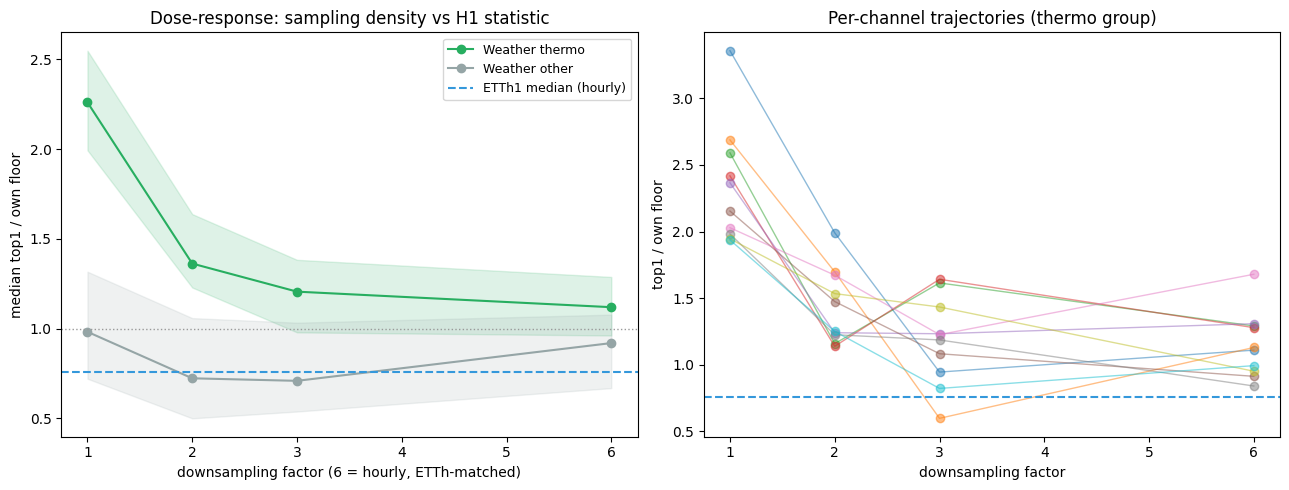

Saved tda_downsample_control.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for grp, color in [('thermo', '#27ae60'), ('other', '#95a5a6')]:
    med = comb[comb.group == grp].groupby('factor').top1_over_floor.median()
    q1 = comb[comb.group == grp].groupby('factor').top1_over_floor.quantile(0.25)
    q3 = comb[comb.group == grp].groupby('factor').top1_over_floor.quantile(0.75)
    ax.plot(med.index, med.values, 'o-', color=color, label=f'Weather {grp}')
    ax.fill_between(med.index, q1.values, q3.values, color=color, alpha=0.15)
ax.axhline(ETTH1_MEDIAN, color='#3498db', ls='--', lw=1.5, label='ETTh1 median (hourly)')
ax.axhline(1.0, color='0.6', ls=':', lw=1)
ax.set_xlabel('downsampling factor (6 = hourly, ETTh-matched)')
ax.set_ylabel('median top1 / own floor')
ax.legend(fontsize=9); ax.set_title('Dose-response: sampling density vs H1 statistic')

ax = axes[1]
for ch in THERMO:
    s = comb[comb.channel == ch].sort_values('factor')
    ax.plot(s.factor, s.top1_over_floor, 'o-', alpha=0.5, lw=1)
ax.axhline(ETTH1_MEDIAN, color='#3498db', ls='--', lw=1.5)
ax.set_xlabel('downsampling factor'); ax.set_ylabel('top1 / own floor')
ax.set_title('Per-channel trajectories (thermo group)')

plt.tight_layout()
plt.savefig('tda_downsample_control.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tda_downsample_control.png")

## Notes

- The factor-6 arm is the decision arm (rate AND span matched to ETTh1).
  Factors 2-3 shape the dose-response but are confounded by span growth.
- tau behaviour is itself diagnostic: at factor 6 the daily cycle is 24
  samples, so tau should drop to ~6-12 for diurnal channels. If tau
  instead pins near MAX_TAU, the MI selector is chasing a slower cycle
  and the arm needs inspection before interpretation.
- n_unique is recorded per channel; any channel whose cloud degenerates
  under downsampling joins the registered exclusion list for downstream
  per-channel analyses.